## Instalação e verificação de hardware
Verifica se as bibliotecas estão instaladas e se o PyTorch reconhece sua GPU para acelerar o treino:

In [4]:
%pip install ultralytics opencv-python matplotlib

import os
import torch
from ultralytics import YOLO

print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Placa de vídeo detectada:", torch.cuda.get_device_name(0))

Note: you may need to restart the kernel to use updated packages.
CUDA disponível: False


## Criação do arquivo de configuração data.yaml
Este comando apenas cria o arquivo de texto de mapeamento de caminhos e classes

In [5]:
yaml_content = """
path: C:/Users/rafae/DocumentsPC/dataset
train: train/images
val: valid/images

names:
  0: Phillips
  1: Allen
  2: Sextavado
"""

with open(r"C:\Users\rafae\DocumentsPC\dataset\data.yaml", "w") as f:
    f.write(yaml_content.strip())

print("data.yaml criado com sucesso!")

data.yaml criado com sucesso!


## Download do modelo base
Baixa os pesos pré-treinados do YOLOv8 na memória

In [3]:
model = YOLO('yolov8n.pt')

## Treinamento do Modelo

In [9]:

results = model.train(
    data=r"C:\Users\rafae\DocumentsPC\dataset\data.yaml",
    epochs=22,
    imgsz=640,
    batch=16,
    name='parafusos_yolov8'
)

Ultralytics 8.4.115  Python-3.13.9 torch-2.13.0+cpu CPU (Intel Core i5-9300HF 2.40GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\rafae\DocumentsPC\dataset\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=22, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/parafusos_yolov8/weights/best.pt, momentum=0.937, mosaic=1.0, mu

KeyboardInterrupt: 

## Teste de Predição e Lógica de Contagem por Classe

Esta célula carregará os pesos finais salvos em best.pt, fará a inferência em uma imagem do conjunto de validação e exibirá a contagem exata de cada tipo de parafuso:


image 1/1 C:\Users\rafae\DocumentsPC\dataset\valid\images\img_0009.png: 640x640 2 Phillipss, 4 Allens, 3 Sextavados, 196.0ms
Speed: 9.7ms preprocess, 196.0ms inference, 257.2ms postprocess per image at shape (1, 3, 640, 640)
--- RELATÓRIO DE CONTAGEM ---
Phillips: 2 unidade(s)
Allen: 4 unidade(s)
Sextavado: 3 unidade(s)
Total na bandeja: 9 parafusos


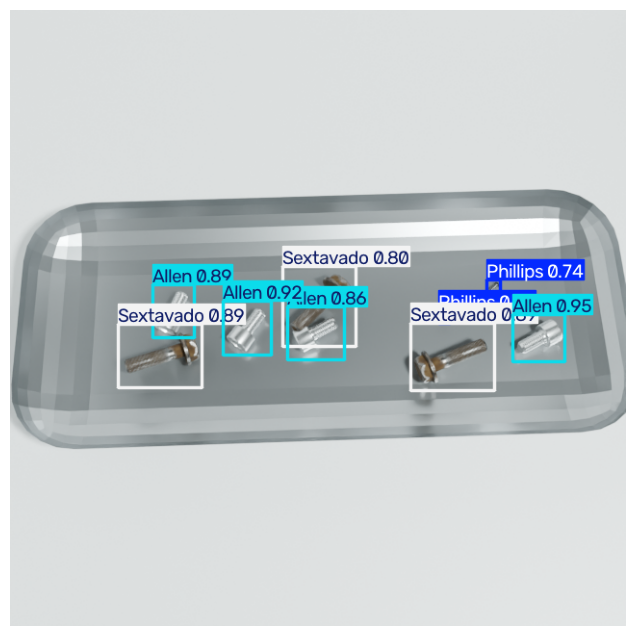

In [1]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

def testar_e_contar(imagem_path):
    # Carrega os melhores pesos treinados (o 'r' antes das aspas evita erros de caminho no Windows)
    model_treinado = YOLO(r'runs/detect/parafusos_yolov8/weights/best.pt')
    
    # Realiza a predição com limiar de confiança de 25%
    results = model_treinado(imagem_path, conf=0.25)
    
    # Dicionário para contagem das classes
    contagem = {'Phillips': 0, 'Allen': 0, 'Sextavado': 0}
    nomes_classes = {0: 'Phillips', 1: 'Allen', 2: 'Sextavado'}
    
    # Iteração sobre os objetos detectados
    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        nome_classe = nomes_classes.get(cls_id, 'Desconhecido')
        if nome_classe in contagem:
            contagem[nome_classe] += 1
            
    print("--- RELATÓRIO DE CONTAGEM ---")
    for classe, qtd in contagem.items():
        print(f"{classe}: {qtd} unidade(s)")
    print(f"Total na bandeja: {sum(contagem.values())} parafusos")
    
    # Exibe a imagem com as bounding boxes desenhadas
    res_plotted = results[0].plot()
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

testar_e_contar(r"C:\Users\rafae\DocumentsPC\dataset\valid\images\img_0009.png")

## Teste em lote de imagens do dataset criado

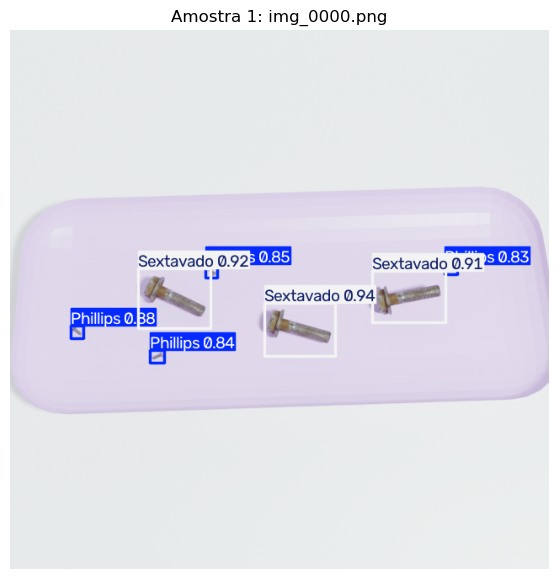

 Parafusos Phillips:  4
 Parafusos Allen:     0
 Parafusos Sextavado: 3
 Total:               7


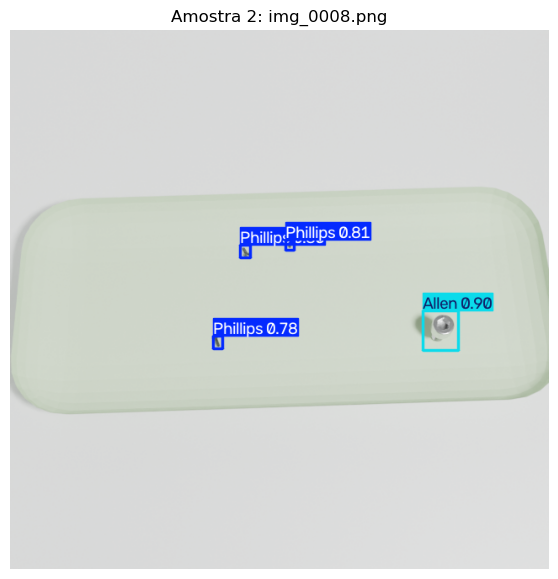

 Parafusos Phillips:  3
 Parafusos Allen:     1
 Parafusos Sextavado: 0
 Total:               4


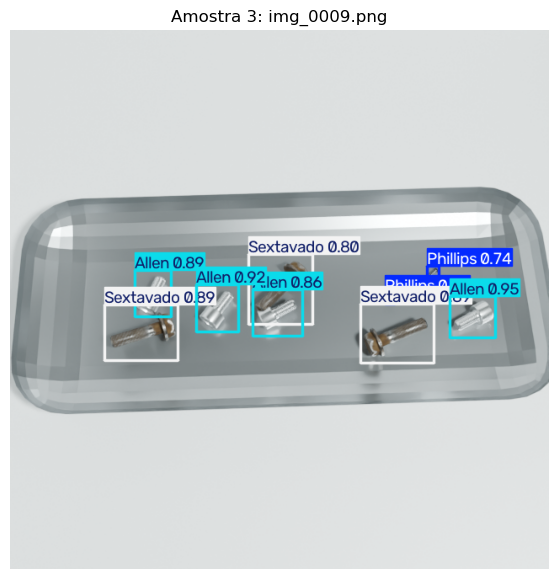

 Parafusos Phillips:  2
 Parafusos Allen:     4
 Parafusos Sextavado: 3
 Total:               9


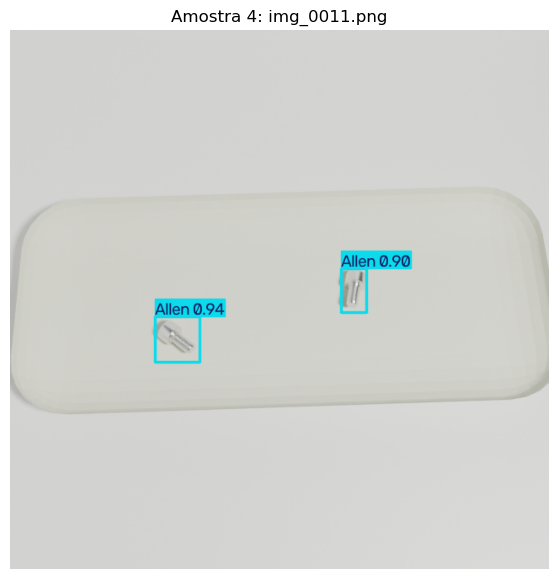

 Parafusos Phillips:  0
 Parafusos Allen:     2
 Parafusos Sextavado: 0
 Total:               2


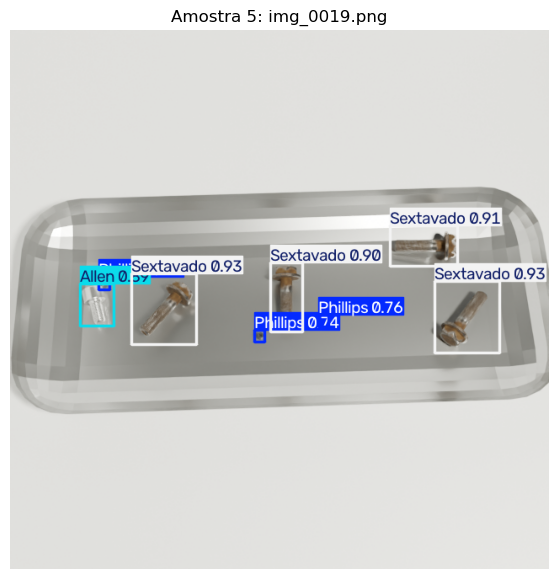

 Parafusos Phillips:  3
 Parafusos Allen:     1
 Parafusos Sextavado: 4
 Total:               8


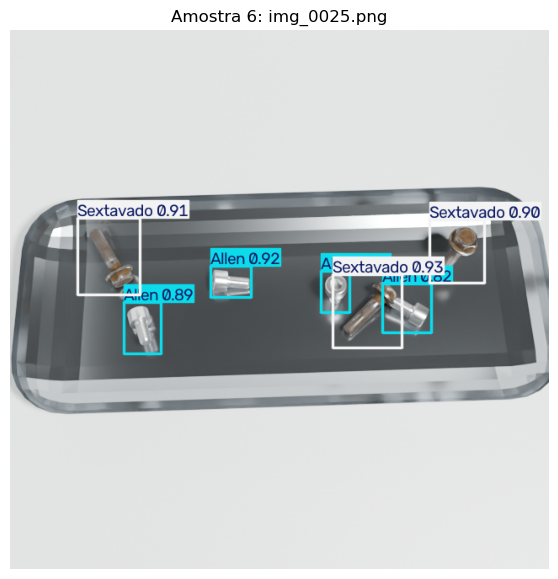

 Parafusos Phillips:  0
 Parafusos Allen:     4
 Parafusos Sextavado: 3
 Total:               7


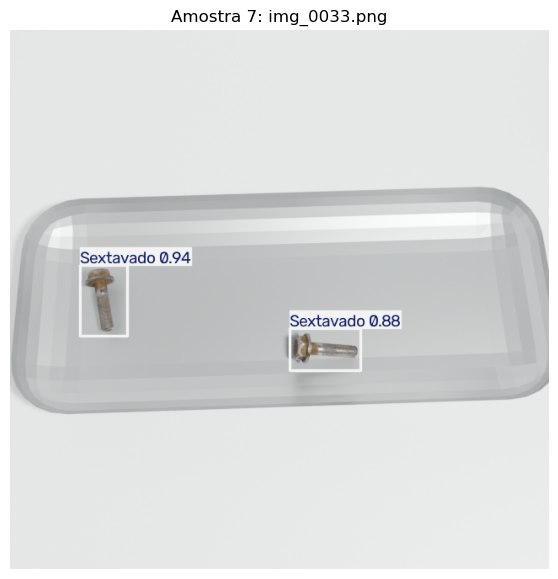

 Parafusos Phillips:  0
 Parafusos Allen:     0
 Parafusos Sextavado: 2
 Total:               2


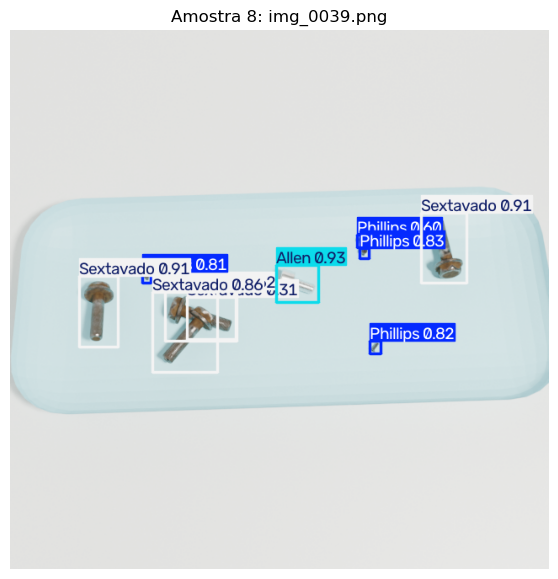

 Parafusos Phillips:  4
 Parafusos Allen:     1
 Parafusos Sextavado: 5
 Total:               10


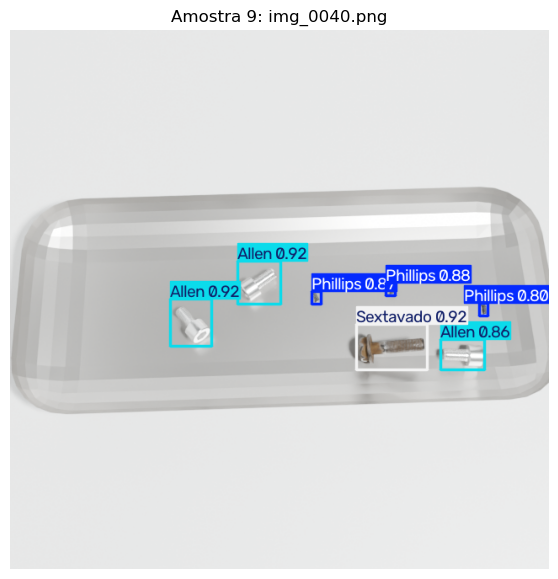

 Parafusos Phillips:  3
 Parafusos Allen:     3
 Parafusos Sextavado: 1
 Total:               7


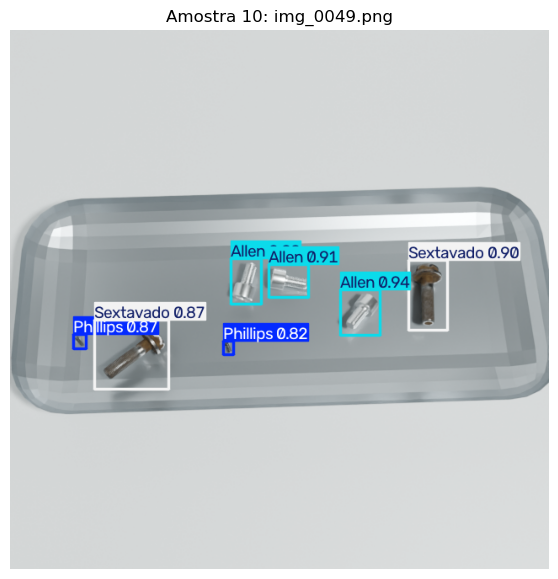

 Parafusos Phillips:  2
 Parafusos Allen:     3
 Parafusos Sextavado: 2
 Total:               7


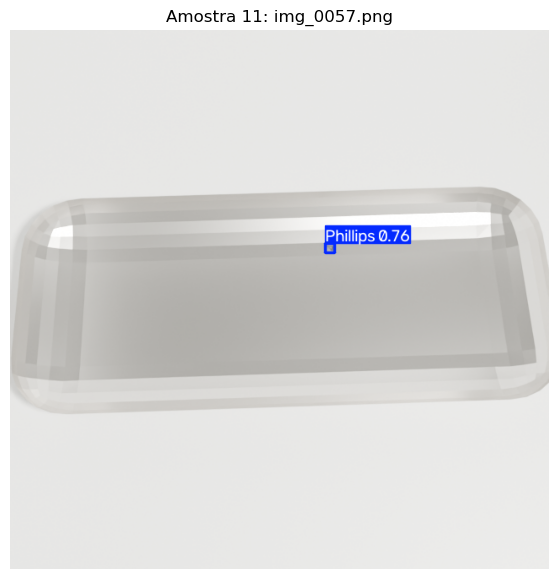

 Parafusos Phillips:  1
 Parafusos Allen:     0
 Parafusos Sextavado: 0
 Total:               1


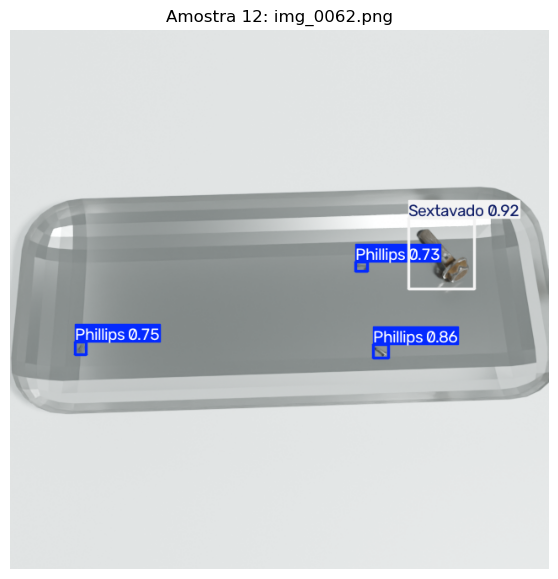

 Parafusos Phillips:  3
 Parafusos Allen:     0
 Parafusos Sextavado: 1
 Total:               4


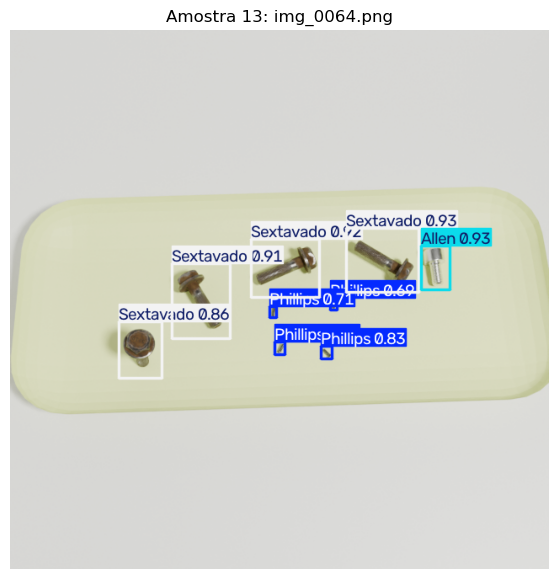

 Parafusos Phillips:  4
 Parafusos Allen:     1
 Parafusos Sextavado: 4
 Total:               9


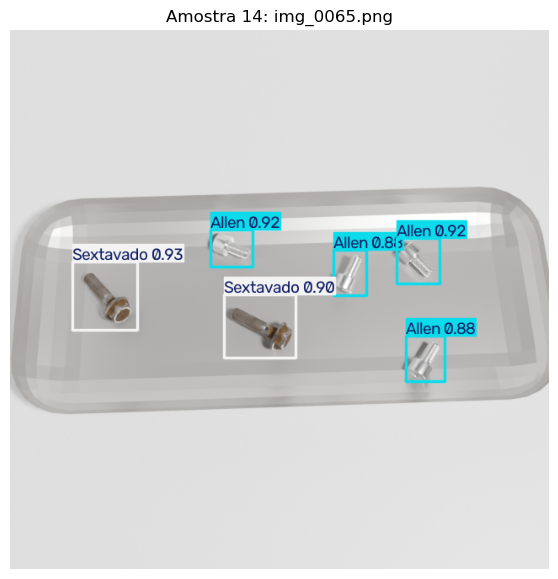

 Parafusos Phillips:  0
 Parafusos Allen:     4
 Parafusos Sextavado: 2
 Total:               6


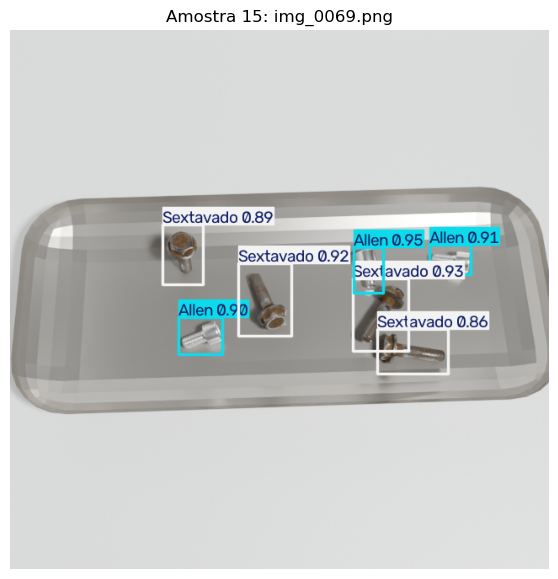

 Parafusos Phillips:  0
 Parafusos Allen:     3
 Parafusos Sextavado: 4
 Total:               7


In [61]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Garantir exibição direta das figuras no Jupyter
%matplotlib inline

# 1. Carrega os melhores pesos do modelo
model = YOLO(r'runs/detect/parafusos_yolov8/weights/best.pt')

# 2. Caminho do diretório de imagens de validação
pasta_imagens = r"C:\Users\rafae\DocumentsPC\dataset\valid\images"

# Seleciona as primeiras 10 imagens da pasta
lista_imagens = glob.glob(os.path.join(pasta_imagens, "*.png"))[:15]

nomes_classes = {0: 'Phillips', 1: 'Allen', 2: 'Sextavado'}

# 3. Loop de inferência, exibição e contagem por imagem
for i, path_img in enumerate(lista_imagens, start=1):
    # Executa a predição desativando os prints padrão no terminal (verbose=False)
    results = model(path_img, conf=0.25, verbose=False)
    
    # Inicializa a contagem zerada para a imagem atual
    contagem = {'Phillips': 0, 'Allen': 0, 'Sextavado': 0}
    
    # Preenche a contagem
    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        nome_classe = nomes_classes.get(cls_id)
        if nome_classe in contagem:
            contagem[nome_classe] += 1
            
    # Renderiza a imagem com as caixas anotadas
    res_plotted = results[0].plot()
    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.title(f"Amostra {i}: {os.path.basename(path_img)}", fontsize=12)
    plt.axis('off')
    plt.show()
    
    print(f" Parafusos Phillips:  {contagem['Phillips']}")
    print(f" Parafusos Allen:     {contagem['Allen']}")
    print(f" Parafusos Sextavado: {contagem['Sextavado']}")
    print(f" Total:               {sum(contagem.values())}")
    print("=" * 45)

## Testando com Imagens reais
Este primeiro comando prepara o ambiente para que seja ppossível executar a próxima célula de código, que contém a URL da imagem que está sendo testada no momento.

In [37]:
# ============================================================
# SETUP - Executar uma vez
# ============================================================

%matplotlib inline
import os
import requests
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Caminho correto do seu modelo treinado
MODEL_PATH = r"runs/detect/parafusos_yolov8/weights/best.pt"
model = YOLO(MODEL_PATH)


def testar_imagem(origem, conf=0.25):
    """
    Roda a detecção e contagem em uma imagem (caminho local ou URL da web).
    """
    # Trata download se for URL, ou usa o caminho local direto
    if origem.startswith("http://") or origem.startswith("https://"):
        image_path = Path("_teste_temp.jpg")
        response = requests.get(origem, timeout=15)
        response.raise_for_status()
        image_path.write_bytes(response.content)
        caminho_final = str(image_path)
    else:
        caminho_final = origem

    # Predição desativando logs de terminal (verbose=False)
    results = model.predict(source=caminho_final, conf=conf, verbose=False)
    result = results[0]

    # Exibe a imagem com as caixas no Jupyter
    annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 7))
    plt.imshow(annotated)
    plt.axis("off")
    plt.show()

    # Dicionário de contagem fixo nas 3 classes
    counts = {'Phillips': 0, 'Allen': 0, 'Sextavado': 0}

    # Preenche a contagem mapeando os IDs capturados
    for box in result.boxes:
        cls_id = int(box.cls[0])
        nome_classe = result.names[cls_id]
        
        # Mapeia para a chave correta no dicionário
        for chave in counts.keys():
            if chave.lower() in nome_classe.lower():
                counts[chave] += 1
                break

    # Impressão do relatório padronizado
    print("=" * 40)
    print(f" Parafusos Phillips:  {counts['Phillips']}")
    print(f" Parafusos Allen:     {counts['Allen']}")
    print(f" Parafusos Sextavado: {counts['Sextavado']}")
    print(f" Total:               {sum(counts.values())}")
    print("=" * 40)

    return counts

# Testando com link de Imagem Real contedo um dos três tipos de parafuso que foi trabalhado.
## Objetivo é avaliar as limitações do modelo treinado apenas com dados sintéticos e potencial "Domain Gap".


# Usaremos as seguintes imagens reais:

https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR5TD-0qOTyGZFqT6yxKYBoP1dRxCJyEg_Fjw8IP5y4TA&s=10

https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTRkCvVcyk_hNf-XN3dCtai6d7NweX7mRWM30nRBQmNgVI3UozrMt59LP4&s=10


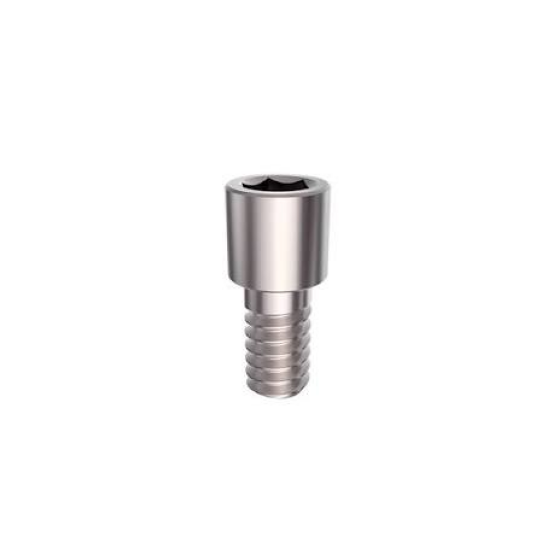

 Parafusos Phillips:  0
 Parafusos Allen:     0
 Parafusos Sextavado: 0
 Total:               0


{'Phillips': 0, 'Allen': 0, 'Sextavado': 0}

In [48]:
# Exemplo 1: Imagem direto da internet
testar_imagem("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR5TD-0qOTyGZFqT6yxKYBoP1dRxCJyEg_Fjw8IP5y4TA&s=10")

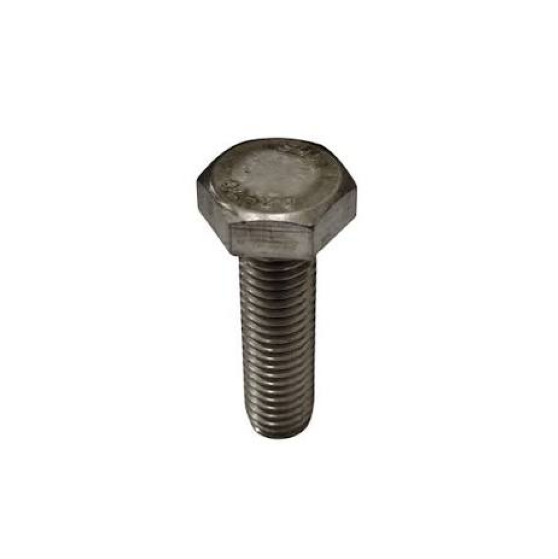

 Parafusos Phillips:  0
 Parafusos Allen:     0
 Parafusos Sextavado: 0
 Total:               0


{'Phillips': 0, 'Allen': 0, 'Sextavado': 0}

In [49]:
# Exemplo 2: Imagem direto da internet 
testar_imagem("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTRkCvVcyk_hNf-XN3dCtai6d7NweX7mRWM30nRBQmNgVI3UozrMt59LP4&s=10")

## Teste com foto tirada por mim

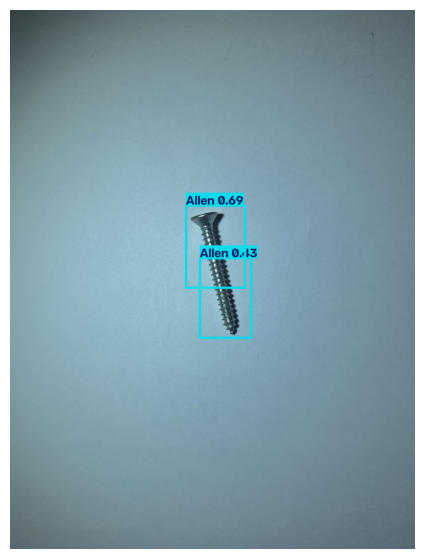

 Parafusos Phillips:  0
 Parafusos Allen:     2
 Parafusos Sextavado: 0
 Total:               2


{'Phillips': 0, 'Allen': 2, 'Sextavado': 0}

In [57]:
caminho_sua_foto = r"C:\Users\rafae\Downloads\foto_parafuso.jpg"
testar_imagem(caminho_sua_foto)

## Após esses testes notamos que o modelo apresentou queda signifigativa de desempenho devido ao domain gap entre o conjunto de treinamento sintético e o domínio das imagens reais